## Librerias

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew
from sklearn.preprocessing import RobustScaler
from scipy.stats.mstats import winsorize


## Manejo de Outliers

Despues de analizar los outliers en el dataset y su distrubucion, se ha decidido aplicar un enfoque de manejo de outliers mas sofisticado. Tomando en cuenta la naturaleza de los datos.

### Outliers tecnicos [Eliminar]

Con esto confirmacmos que no haya outliers causados por errores en la data de entrada, como precios imposibles, volúmenes negativos o relaciones imposibles entre variables.

```python

In [66]:


def detectar_outliers_tecnicos(df):
    """
    Detecta outliers técnicos (errores de datos) en dataset de criptomonedas
    """
    
    outliers_tecnicos = pd.DataFrame()
    
    # 1. VALORES IMPOSIBLES - PRECIOS
    
    # Precios negativos o cero
    precios_invalidos = df[df['price'] <= 0]
    if len(precios_invalidos) > 0:
        print(f" Encontrados {len(precios_invalidos)} precios <= 0")
        print(precios_invalidos[['price', 'market_cap']].head())
        outliers_tecnicos = pd.concat([outliers_tecnicos, precios_invalidos])
    else:
        print(" No hay precios negativos o cero")
    
    # 2. VALORES IMPOSIBLES - VOLUMEN

    
    # Volumen negativo
    volumen_negativo = df[df['volume'] < 0]
    if len(volumen_negativo) > 0:
        print(f" Encontrados {len(volumen_negativo)} volúmenes negativos")
        outliers_tecnicos = pd.concat([outliers_tecnicos, volumen_negativo])
    else:
        print(" No hay volúmenes negativos")
    
    # 3. RELACIONES IMPOSIBLES
    print("\n3. DETECTANDO RELACIONES IMPOSIBLES:")
    print("-" * 40)
    
    # Volumen mayor que 10x el market cap (sospechoso)
    df_temp = df.copy()
    df_temp['volume_to_mcap_ratio'] = df_temp['volume'] / df_temp['market_cap']
    relaciones_raras = df_temp[df_temp['volume_to_mcap_ratio'] > 10]
    
    if len(relaciones_raras) > 0:
        print(f"  Encontrados {len(relaciones_raras)} casos donde volumen > 10x market cap")
        print("Los primeros 5 casos:")
        print(relaciones_raras[['volume', 'market_cap', 'volume_to_mcap_ratio']].head())
        # Estos son sospechosos pero no necesariamente errores
    else:
        print(" Relaciones volumen/market_cap normales")
    
    # 4. CAMBIOS EXTREMOS IMPOSIBLES
    print("\n4. DETECTANDO CAMBIOS IMPOSIBLES EN PRECIO:")
    print("-" * 47)
    
    # Cambios de precio > 1000% en un día (99.9% seguro que es error)
    cambios_extremos = df[abs(df['price_change_%']) > 1000]
    if len(cambios_extremos) > 0:
        print(f" Encontrados {len(cambios_extremos)} cambios > 1000%")
        print(cambios_extremos[['price_change_%', 'price', 'market_cap']].head())
        outliers_tecnicos = pd.concat([outliers_tecnicos, cambios_extremos])
    else:
        print(" No hay cambios de precio imposibles")
    
    # 5. VALORES FALTANTES O INFINITOS
    print("\n5. DETECTANDO VALORES FALTANTES/INFINITOS:")
    print("-" * 47)
    
    # NaN values
    nan_count = df.isnull().sum()
    if nan_count.sum() > 0:
        print(" Valores faltantes encontrados:")
        print(nan_count[nan_count > 0])
    else:
        print(" No hay valores faltantes")
    
    # Infinite values
    inf_mask = np.isinf(df.select_dtypes(include=[np.number]))
    if inf_mask.any().any():
        print(" Valores infinitos encontrados")
        inf_cols = inf_mask.any()[inf_mask.any()].index.tolist()
        print(f"Columnas con infinitos: {inf_cols}")
    else:
        print(" No hay valores infinitos")
    
    # RESUMEN
    print("\n" + "="*60)
    print("RESUMEN DE OUTLIERS TÉCNICOS")
    print("="*60)
    
    if len(outliers_tecnicos) > 0:
        print(f" Total de outliers técnicos detectados: {len(outliers_tecnicos)}")
        print(f" Porcentaje del dataset: {len(outliers_tecnicos)/len(df)*100:.2f}%")
        print("\nRecomendación: ELIMINAR estos registros")
        
        return outliers_tecnicos.index.unique()
    else:
        print(" No se detectaron outliers técnicos")
        print(" Los datos parecen estar limpios")
        return []



# Cargar tu dataset
df = pd.read_csv(r"C:\Users\rosar\RufoEsEterno\MachineLearning\TP-Machine-Learning\data\eda_data.csv")

# Detectar outliers técnicos
indices_outliers = detectar_outliers_tecnicos(df)



 No hay precios negativos o cero
 No hay volúmenes negativos

3. DETECTANDO RELACIONES IMPOSIBLES:
----------------------------------------
 Relaciones volumen/market_cap normales

4. DETECTANDO CAMBIOS IMPOSIBLES EN PRECIO:
-----------------------------------------------
 No hay cambios de precio imposibles

5. DETECTANDO VALORES FALTANTES/INFINITOS:
-----------------------------------------------
 No hay valores faltantes
 No hay valores infinitos

RESUMEN DE OUTLIERS TÉCNICOS
 No se detectaron outliers técnicos
 Los datos parecen estar limpios


### Outliers de Mercado Extremos (TRANSFORMAR)

### Transformaciones logaritmicas para variables muy asimetricas

Estas son observaciones reales, pero distorsionan el entrenamiento de modelos sensibles a escala.

Especialmente importante en redes neuronales (MLP, LSTM) donde los valores extremos pueden provocar explosión o vanishing gradient.

In [67]:
df_transformado = df.copy()
transformaciones_aplicadas = {}

In [68]:
variables = [
    "price", "market_cap", "volume", "tvl_usd",
    "volume_to_marketcap", "price_change_%",
    "market_cap_trend", "tvl_trend"
]

In [69]:
def analizar_variable(df, col):
    print(f"\nVariable: {col}")
    # Filtrar valores no nulos y positivos (para log)
    serie = df[col].dropna()
    serie_pos = serie[serie >= 0]

    # Calcular skewness original
    skw = skew(serie)
    print(f"Asimetría (skew) original: {skw:.2f}")

    # Plot original
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    sns.histplot(serie, bins=50, kde=True, color='steelblue')
    plt.title(f"{col} - Distribución original")

    # Plot log(x+1)
    if (serie_pos > 0).sum() > 0:
        serie_log = np.log1p(serie_pos)
        skw_log = skew(serie_log)
        print(f"Asimetría (skew) log(x+1): {skw_log:.2f}")

        plt.subplot(1, 2, 2)
        sns.histplot(serie_log, bins=50, kde=True, color='orange')
        plt.title(f"{col} - Distribución log(x+1)")
    else:
        print("No se puede aplicar log(x+1): no hay valores positivos.")

    plt.tight_layout()
    plt.show()


Variable: price
Asimetría (skew) original: 1.43


Asimetría (skew) log(x+1): 0.93


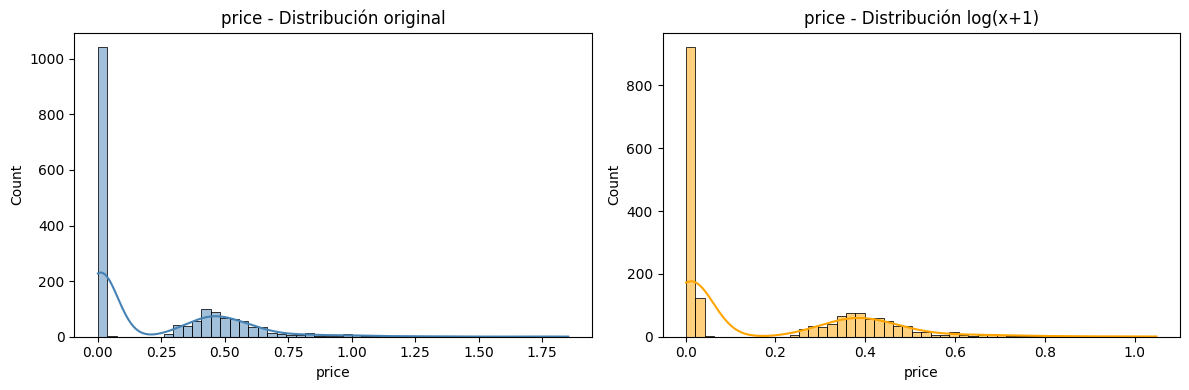


Variable: market_cap
Asimetría (skew) original: 0.93
Asimetría (skew) log(x+1): -0.44


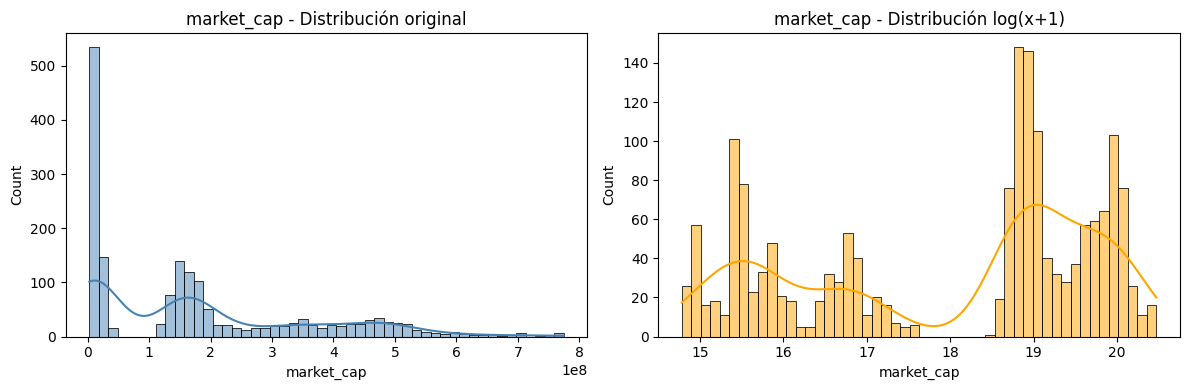


Variable: volume
Asimetría (skew) original: 5.99
Asimetría (skew) log(x+1): -0.51


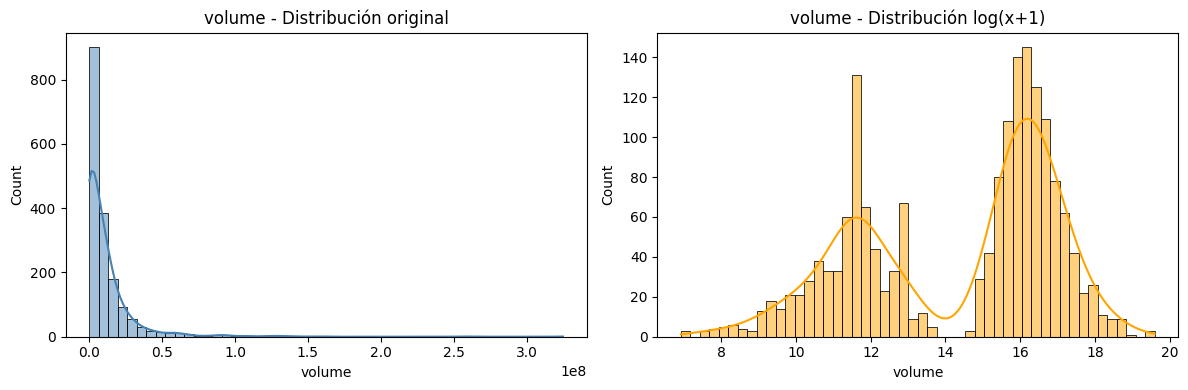


Variable: tvl_usd
Asimetría (skew) original: 1.60
Asimetría (skew) log(x+1): 0.91


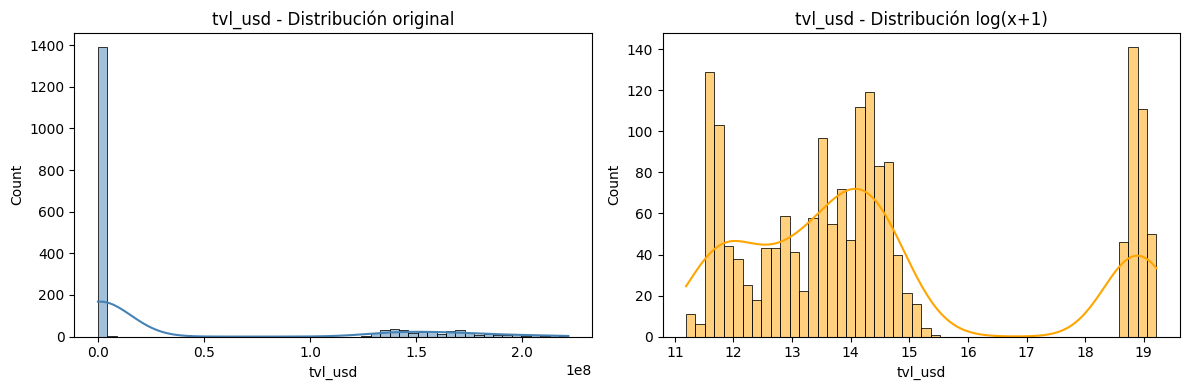


Variable: volume_to_marketcap
Asimetría (skew) original: 4.41
Asimetría (skew) log(x+1): 3.38


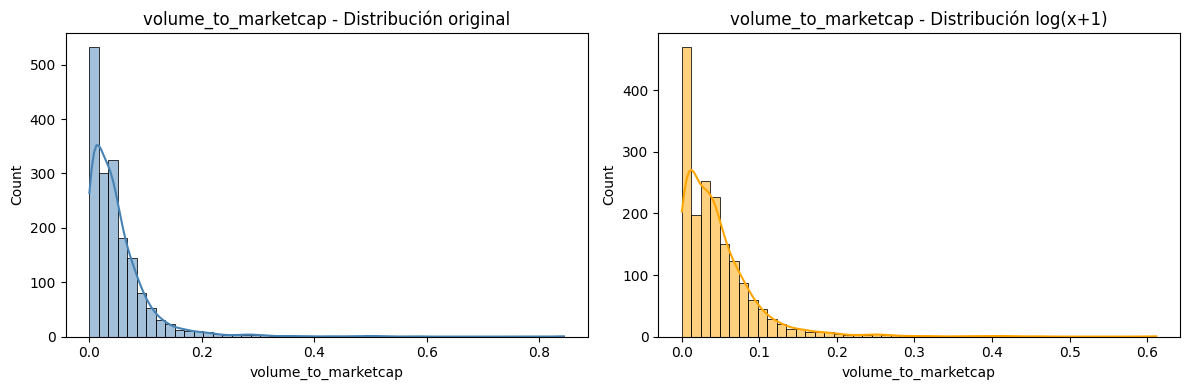


Variable: price_change_%
Asimetría (skew) original: 0.85
Asimetría (skew) log(x+1): 0.27


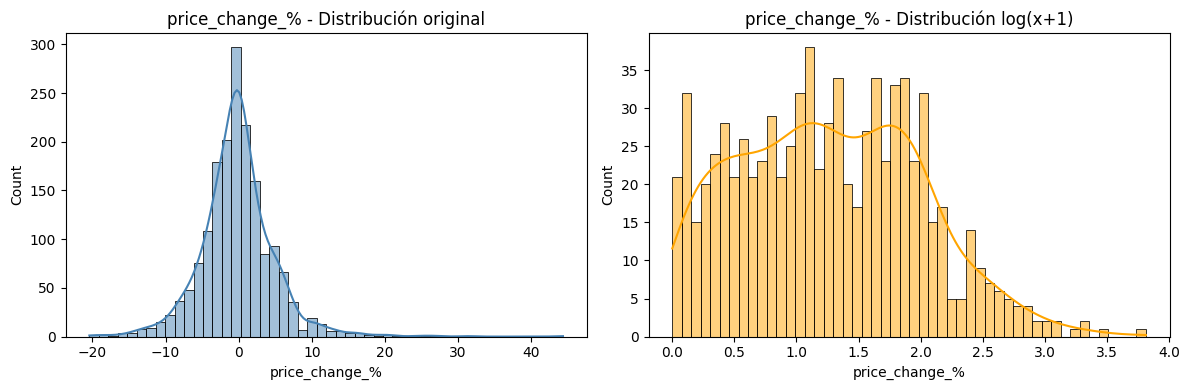


Variable: market_cap_trend
Asimetría (skew) original: 0.87
Asimetría (skew) log(x+1): 0.30


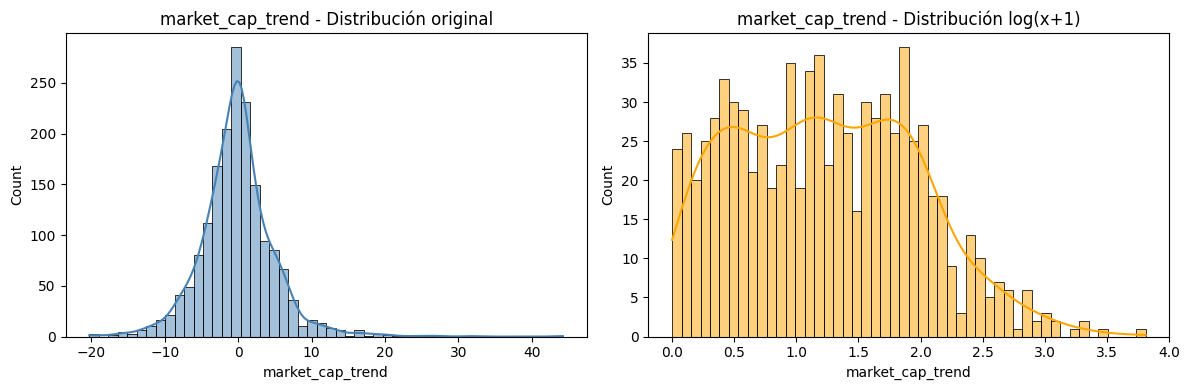


Variable: tvl_trend
Asimetría (skew) original: 8.01
Asimetría (skew) log(x+1): 0.59


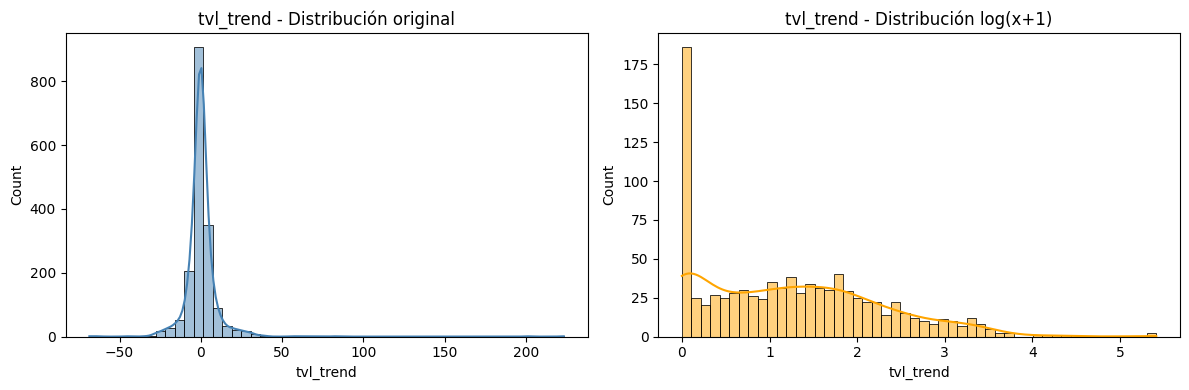

In [70]:
for var in variables:
    if var in df.columns:
        analizar_variable(df, var)
    else:
        print(f"Variable '{var}' no está en el DataFrame.")

In [71]:
df_transformado["price"] = np.log1p(df["price"])
df_transformado["market_cap"] = np.log1p(df["market_cap"])
df_transformado["volume"] = np.log1p(df["volume"])
df_transformado["tvl_usd"] = np.log1p(df["tvl_usd"])

En el contexto de datos financieros de criptoactivos, variables como price, market_cap, volume y tvl_usd presentan distribuciones altamente asimétricas, con valores extremos que distorsionan las métricas estadísticas y el aprendizaje de modelos. La transformación logarítmica (log(x+1)) permite reducir esta asimetría y comprimir la escala de magnitudes, estabilizando la varianza y haciendo que los patrones subyacentes sean más aprendibles para modelos como MLP o LSTM. Aplicar log(x+1) a estas variables mejora su distribución sin eliminar información estructural importante, lo que contribuye a entrenamientos más robustos y generalizables. Esta transformación es especialmente útil cuando se trabaja con datos que cubren órdenes de magnitud distintas entre activos o períodos.

### Winsorización

In [72]:
df_wins = df_transformado.copy()

In [73]:
vars_winsorizar = [
'price', 'market_cap', 'volume', 'tvl_usd',
'volume_to_marketcap', 'price_change_%',
'market_cap_trend', 'tvl_trend'
]

In [74]:

for col in vars_winsorizar:
    if col in df_wins.columns:
        arr = df_wins[col].values
        wins_arr = winsorize(arr, limits=[0.01, 0.01])
        df_wins[f'wins_{col}'] = wins_arr.data 
    else:
        print(f"{col} no existe en el DataFrame")

In [75]:
def graficar_winsorizacion(df, col, limits=(0.01, 0.01)):
    serie = df[col].dropna().values
    serie_wins = winsorize(serie, limits=limits).data # array limpio
    fig, axs = plt.subplots(1, 3, figsize=(18, 4))

    # Histograma original
    sns.histplot(serie, bins=50, kde=True, ax=axs[0], color='steelblue')
    axs[0].set_title(f'{col} - Original')

# Histograma winsorizado
    sns.histplot(serie_wins, bins=50, kde=True, ax=axs[1], color='orange')
    axs[1].set_title(f'{col} - Winsorizado')

# Boxplots para comparar
    sns.boxplot(data=[serie, serie_wins], ax=axs[2])
    axs[2].set_xticklabels(['Original', 'Winsorizado'])
    axs[2].set_title(f'{col} - Boxplot')

    plt.tight_layout()
    plt.show()


C:\Users\rosar\AppData\Local\Temp\ipykernel_3380\2294285761.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[2].set_xticklabels(['Original', 'Winsorizado'])


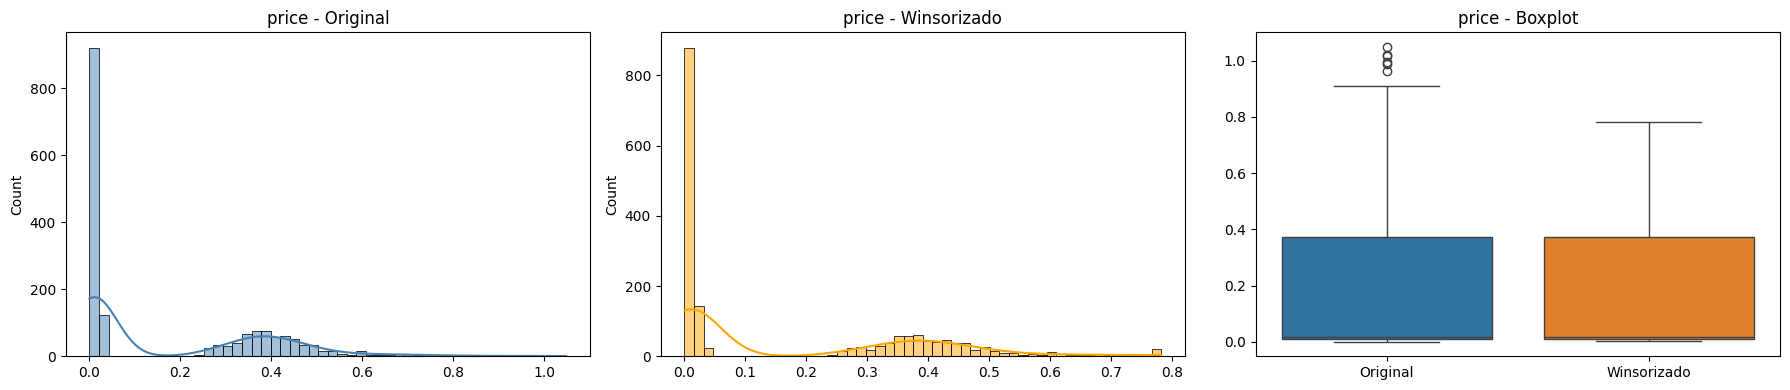

C:\Users\rosar\AppData\Local\Temp\ipykernel_3380\2294285761.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[2].set_xticklabels(['Original', 'Winsorizado'])


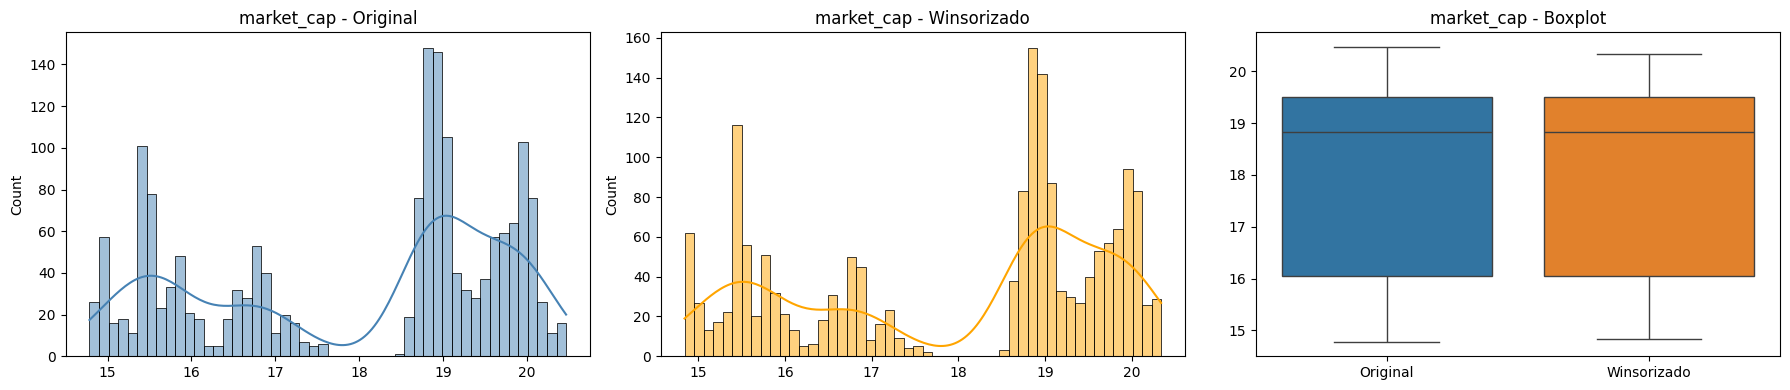

C:\Users\rosar\AppData\Local\Temp\ipykernel_3380\2294285761.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[2].set_xticklabels(['Original', 'Winsorizado'])


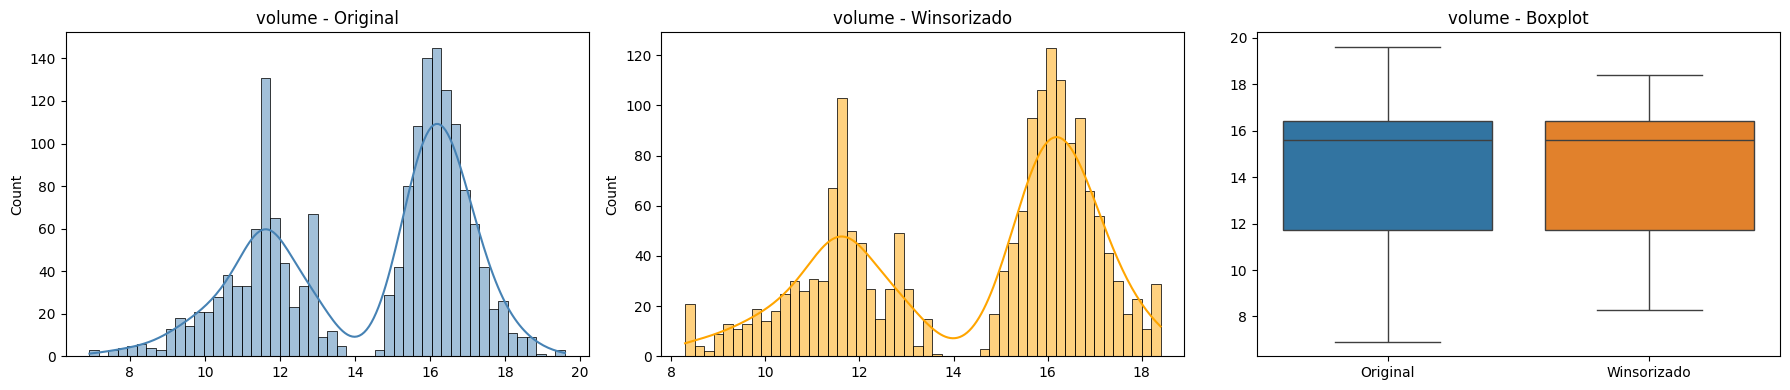

C:\Users\rosar\AppData\Local\Temp\ipykernel_3380\2294285761.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[2].set_xticklabels(['Original', 'Winsorizado'])


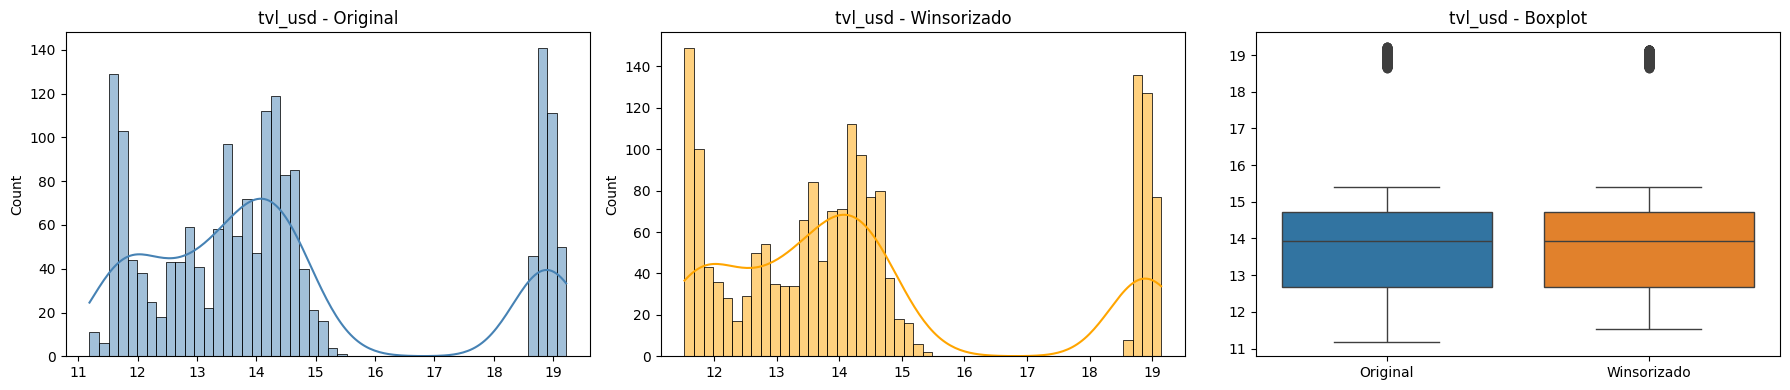

C:\Users\rosar\AppData\Local\Temp\ipykernel_3380\2294285761.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[2].set_xticklabels(['Original', 'Winsorizado'])


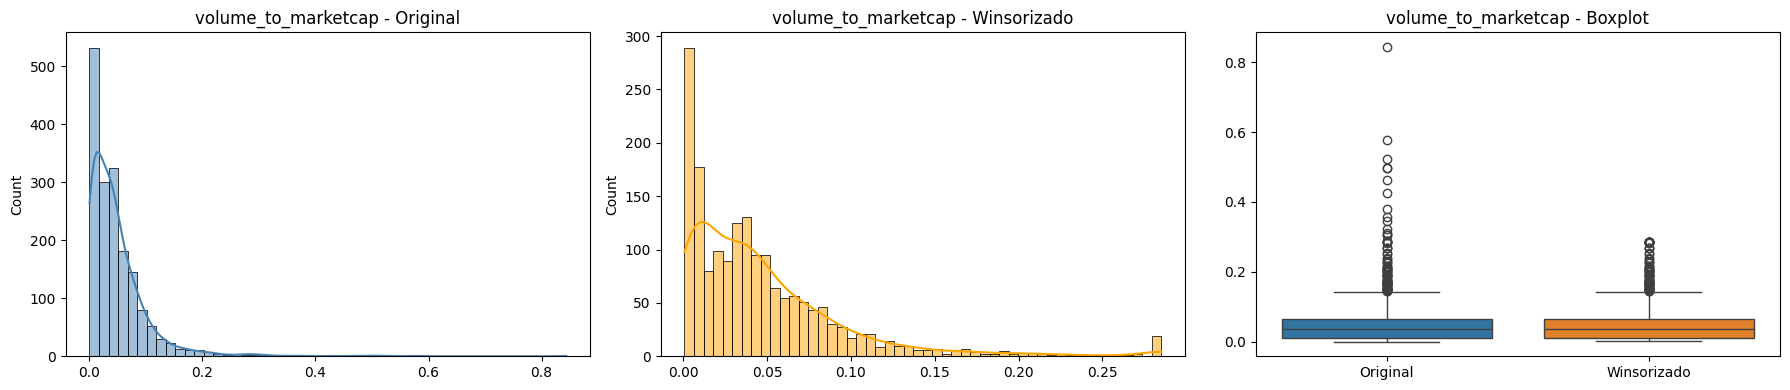

C:\Users\rosar\AppData\Local\Temp\ipykernel_3380\2294285761.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[2].set_xticklabels(['Original', 'Winsorizado'])


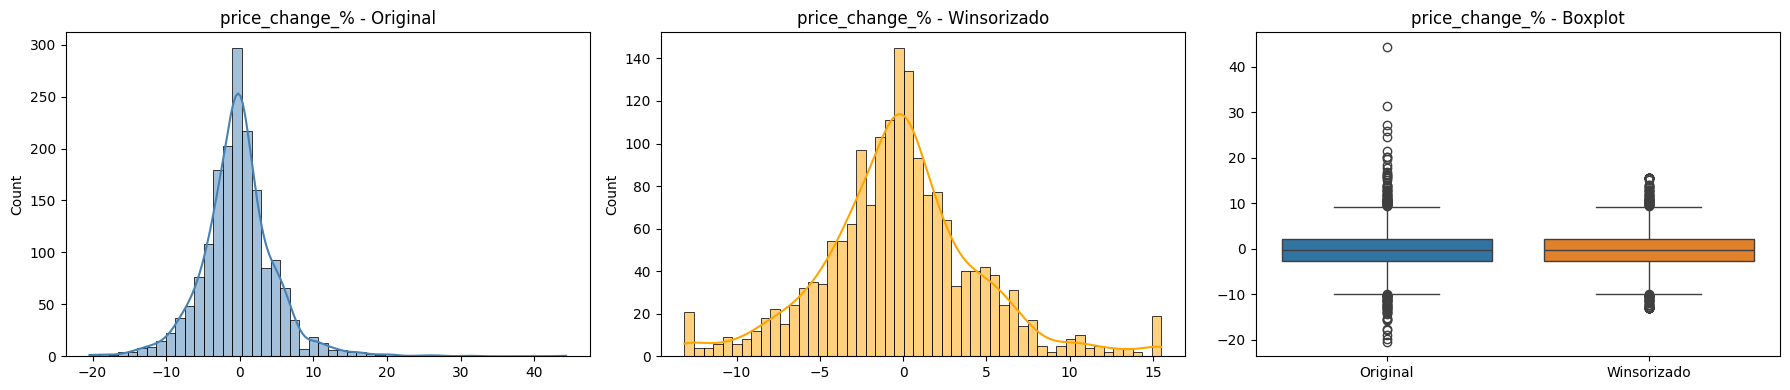

C:\Users\rosar\AppData\Local\Temp\ipykernel_3380\2294285761.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[2].set_xticklabels(['Original', 'Winsorizado'])


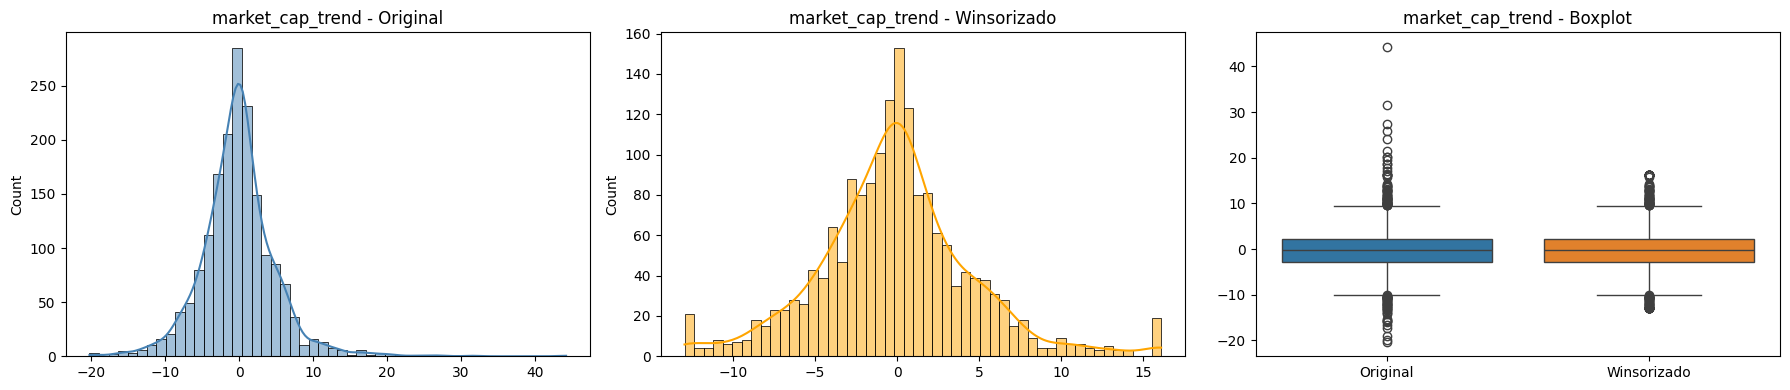

C:\Users\rosar\AppData\Local\Temp\ipykernel_3380\2294285761.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[2].set_xticklabels(['Original', 'Winsorizado'])


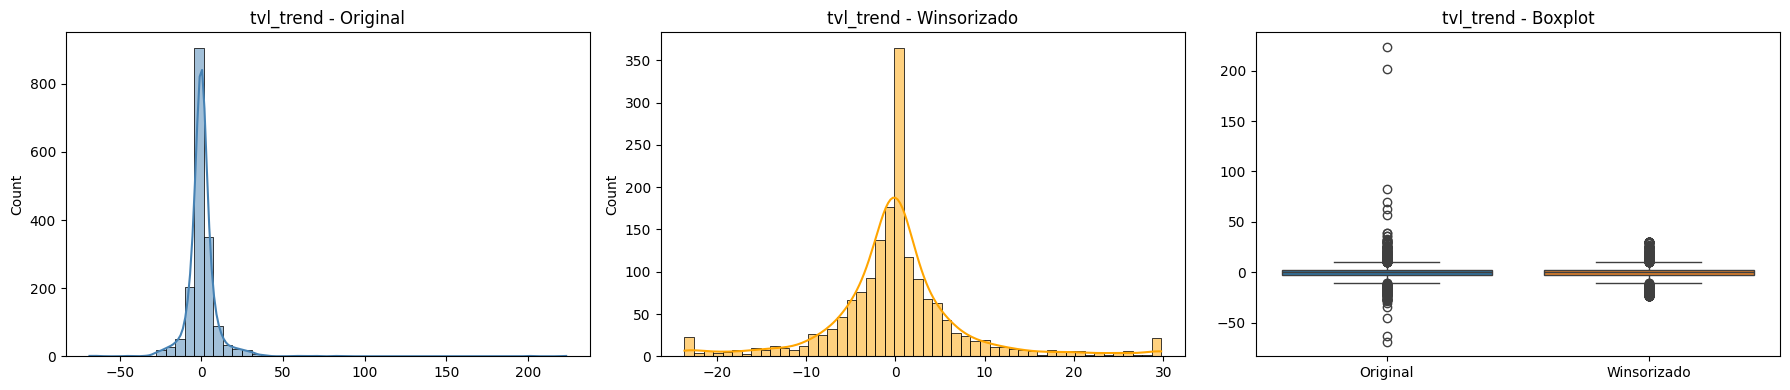

In [76]:
graficar_winsorizacion(df_transformado, 'price')
graficar_winsorizacion(df_transformado, 'market_cap')
graficar_winsorizacion(df_transformado, 'volume')
graficar_winsorizacion(df_transformado, 'tvl_usd')
graficar_winsorizacion(df_transformado, 'volume_to_marketcap')
graficar_winsorizacion(df_transformado, 'price_change_%')
graficar_winsorizacion(df_transformado, 'market_cap_trend')
graficar_winsorizacion(df_transformado, 'tvl_trend')

En contextos financieros como los mercados cripto, es común encontrar valores extremos que representan eventos puntuales o picos abruptos, pero que distorsionan las métricas y afectan la estabilidad de modelos sensibles a escala como redes neuronales. La winsorización limita el impacto de estos valores atípicos recortando los extremos superiores e inferiores a un umbral definido (por ejemplo, percentil 1 y 99), sin eliminar la observación. Esta técnica es útil después de aplicar log(x+1), ya que suaviza aún más la distribución y evita que valores excepcionales dominen el proceso de entrenamiento del modelo.

### 